In [10]:
import os
import kagglehub
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Pretrained ResNet18
# ResNet18 is an 18 layer convolutional neural network which is designed to solve vanishing
# gradients problem by letting gradients flow through a shortcut path
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)

# Remove final classification layer as not required
image_model = nn.Sequential(*list(resnet.children())[:-1])

image_model = image_model.to(device)
image_model.eval()

transform = weights.transforms()  # resize, convert to tensor and normalize

cuda


In [11]:
DATA_DIR = "/kaggle/input/competitions/shopee-product-matching"

train = pd.read_csv(f"{DATA_DIR}/train.csv")

print("Shape:", train.shape)
train.head()

Shape: (34250, 5)


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [12]:
train_indices = []
val_indices = []

for label, group in train.groupby("label_group"):
    indices_group = group.index.tolist()

    # Groups with only one product stay entirely in training
    if len(indices_group) == 1:
        train_indices.extend(indices_group)
    else:
        # Put 20% in validation, but keep at least 1 in training
        n_val = max(1, int(len(indices_group) * 0.2))
        n_val = min(n_val, len(indices_group) - 1)

        val_group, train_group = train_test_split(
            indices_group,
            test_size=len(indices_group) - n_val,
            random_state=42
        )

        val_indices.extend(val_group)
        train_indices.extend(train_group)

train_data = train.loc[train_indices].reset_index(drop=True)
val_data = train.loc[val_indices].reset_index(drop=True)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)

Train: (22676, 5)
Validation: (11574, 5)


In [13]:
class ShopeeImageDataset(Dataset):
    def __init__(self, df, image_dir, transform):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.df.iloc[idx]["image"]
        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        return image


IMAGE_DIR = os.path.join(DATA_DIR, "train_images")

train_image_dataset = ShopeeImageDataset(train_data, IMAGE_DIR, transform)
val_image_dataset = ShopeeImageDataset(val_data, IMAGE_DIR, transform)

train_image_loader = DataLoader(
    train_image_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

val_image_loader = DataLoader(
    val_image_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

In [14]:
def get_embeddings(loader):
    """Run every batch through ResNet18 and return an (N, 512) array."""
    all_embeddings = []

    with torch.no_grad():
        for images in tqdm(loader):
            images = images.to(device)
            batch_embeddings = image_model(images)        # (B, 512, 1, 1)
            batch_embeddings = batch_embeddings.flatten(1)  # (B, 512)
            all_embeddings.append(batch_embeddings.cpu().numpy())

    return np.concatenate(all_embeddings, axis=0)


train_embeddings = get_embeddings(train_image_loader)
val_embeddings = get_embeddings(val_image_loader)

print(train_embeddings.shape, val_embeddings.shape)

  0%|          | 0/355 [00:00<?, ?it/s]

(22676, 512) (11574, 512)


In [16]:
# Find the 10 most visually similar training images for every validation image
image_knn = NearestNeighbors(
    n_neighbors=10,
    metric="cosine",
    n_jobs=-1
)

image_knn.fit(train_embeddings)

image_distances, image_indices = image_knn.kneighbors(
    val_embeddings
)

image_similarities = 1 - image_distances

print(image_similarities.shape)

(11574, 10)


In [21]:
thresholds = np.arange(0.1, 1.0, 0.05)
image_f1_scores_threshold = []

for threshold in thresholds:
    sample_f1 = []

    for i in range(len(val_data)):

        true_matches = set(
            train_data[
                train_data["label_group"] == val_data.iloc[i]["label_group"]
            ]["posting_id"]
        )

        predicted_matches = {
            train_data.iloc[j]["posting_id"]
            for j, sim in zip(image_indices[i], image_similarities[i])
            if sim >= threshold
        }

        intersection = len(true_matches & predicted_matches)

        if len(predicted_matches) == 0:
            f1 = 0.0
        else:
            f1 = 2 * intersection / (
                len(true_matches) + len(predicted_matches)
            )

        sample_f1.append(f1)

    image_f1_scores_threshold.append(np.mean(sample_f1))


best_idx = np.argmax(image_f1_scores_threshold)

print("Best threshold:", thresholds[best_idx])
print("Best image F1:", image_f1_scores_threshold[best_idx])

Best threshold: 0.8500000000000002
Best image F1: 0.3901706729121051


NameError: name 'plt' is not defined

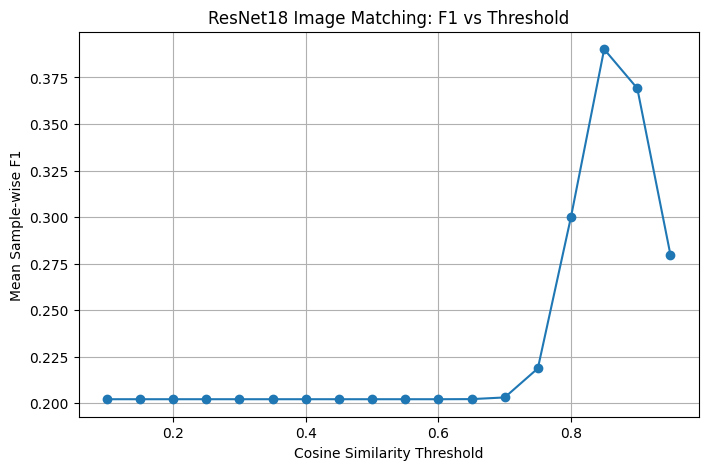

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(thresholds, image_f1_scores_threshold, marker="o")
plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Mean Sample-wise F1")
plt.title("ResNet18 Image Matching: F1 vs Threshold")
plt.grid(True)
plt.show()

In [23]:
best_idx = np.argmax(image_f1_scores_threshold)

best_threshold = thresholds[best_idx]
best_f1 = image_f1_scores_threshold[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.8500000000000002
Best F1: 0.3901706729121051


In [19]:
np.save("train_embeddings.npy", train_embeddings)
np.save("val_embeddings.npy", val_embeddings)